# Five Zones Scatter Plots
Visualizing curved lines, straight lines, and double spheres related to Five Zones images.

In [14]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

## 1. Data Loading and Merging

In [15]:
# Load data
df = pd.read_csv('full_image_data_feb_25.csv', low_memory=False)
books = pd.read_csv('full_book_data_feb_25.csv', low_memory=False)
vt = pd.read_excel('/Users/nogashlomi/projects/Image_data/visual_tags/VT_2.4_five_zones.xlsx')

# Merge printers/publishers
printer_pub = books[['book', 'printers', 'publishers']].drop_duplicates(subset=['book'])
df = df.merge(printer_pub, on='book', how='left')

## 2. Filtering Logic

In [16]:
# Filter for target clusters from visual tags
curved_clusters = vt[vt['motion of the sun two dimensional rep curved line'] == 'yes']['cluster_name'].tolist()
straight_clusters = vt[vt['motion of the sun two dimensional rep straight line'] == 'yes']['cluster_name'].tolist()
double_sphere_clusters = vt[vt['earth and cosmos'] == 'yes']['cluster_name'].tolist()

target_clusters = set(curved_clusters + straight_clusters + double_sphere_clusters)

# Filter df
filtered_df = df[df['cluster_name'].isin(target_clusters)].copy()

# Add category for visualization
def get_category(row):
    cats = []
    if row['cluster_name'] in curved_clusters: cats.append('Curved Line')
    if row['cluster_name'] in straight_clusters: cats.append('Straight Line')
    if row['cluster_name'] in double_sphere_clusters: cats.append('Double Sphere')
    return ', '.join(cats)

filtered_df['category'] = filtered_df.apply(get_category, axis=1)

# Clean up for plotting
filtered_df['custom_identifier_str'] = filtered_df['custom_identifier'].astype(str)
filtered_df['year'] = pd.to_numeric(filtered_df['year'], errors='coerce')
plot_df = filtered_df.dropna(subset=['year', 'place', 'custom_identifier']).copy()
plot_df = plot_df.sort_values(by=['year'])
print(f"Total rows for plotting: {len(plot_df)}")

Total rows for plotting: 649


## 3. Static Scatter Plot (Y=ID, Color=Place)

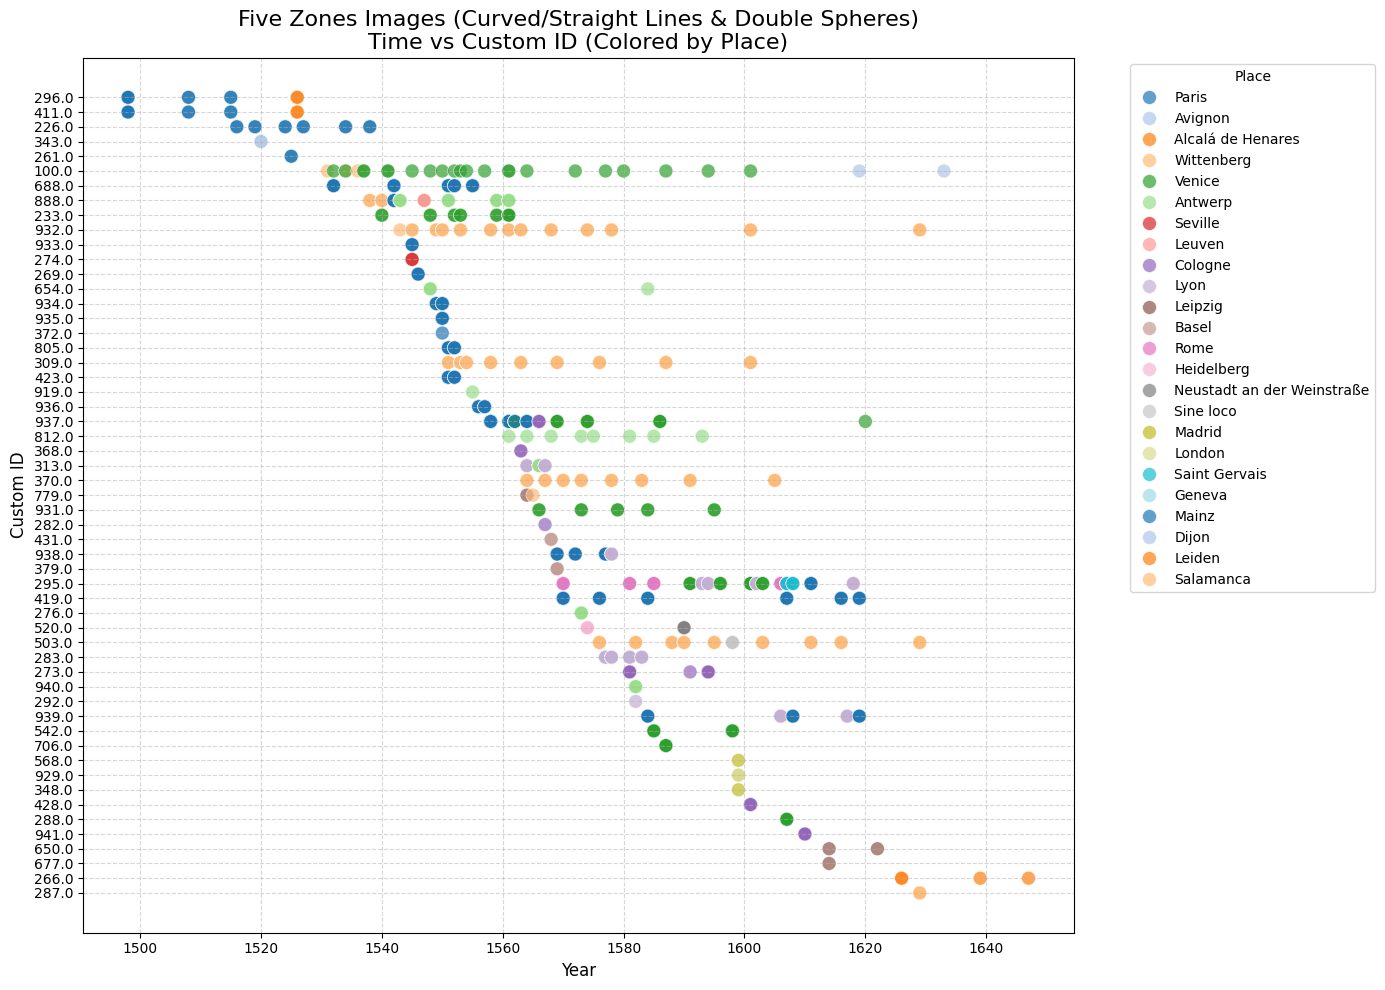

In [17]:
# Static Scatter Plot (Y = Custom ID, Color = Place)
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=plot_df,
    x='year',
    y='custom_identifier_str',
    hue='place',
    palette='tab20',
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Five Zones Images (Curved/Straight Lines & Double Spheres)\nTime vs Custom ID (Colored by Place)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Custom ID', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
plt.tight_layout()

plt.savefig('five_zones_scatter_by_id.png', dpi=300)
plt.show()

## 4. Interactive Scatter Plot

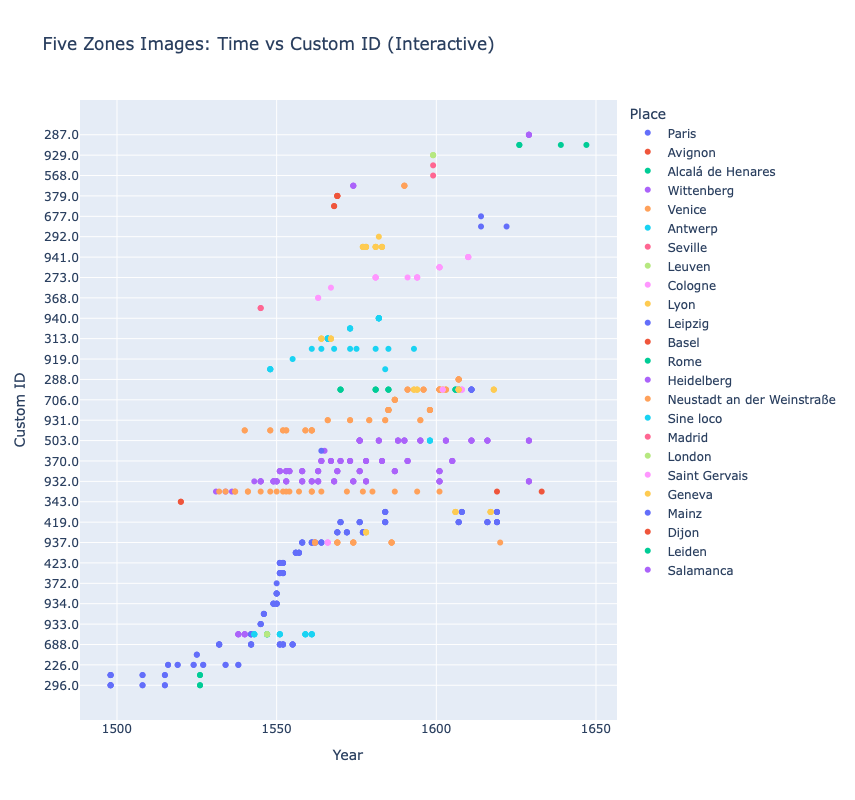

In [18]:
# Interactive Scatter Plot
fig = px.scatter(
    plot_df,
    x='year',
    y='custom_identifier_str',
    color='place',
    hover_data=['cluster_name', 'category', 'part_or_adaption_label', 'book'],
    title='Five Zones Images: Time vs Custom ID (Interactive)',
    labels={'custom_identifier_str': 'Custom ID', 'year': 'Year', 'place': 'Place'}
)

fig.update_layout(height=800)
fig.show()

## 5. Individual Scatter Plots

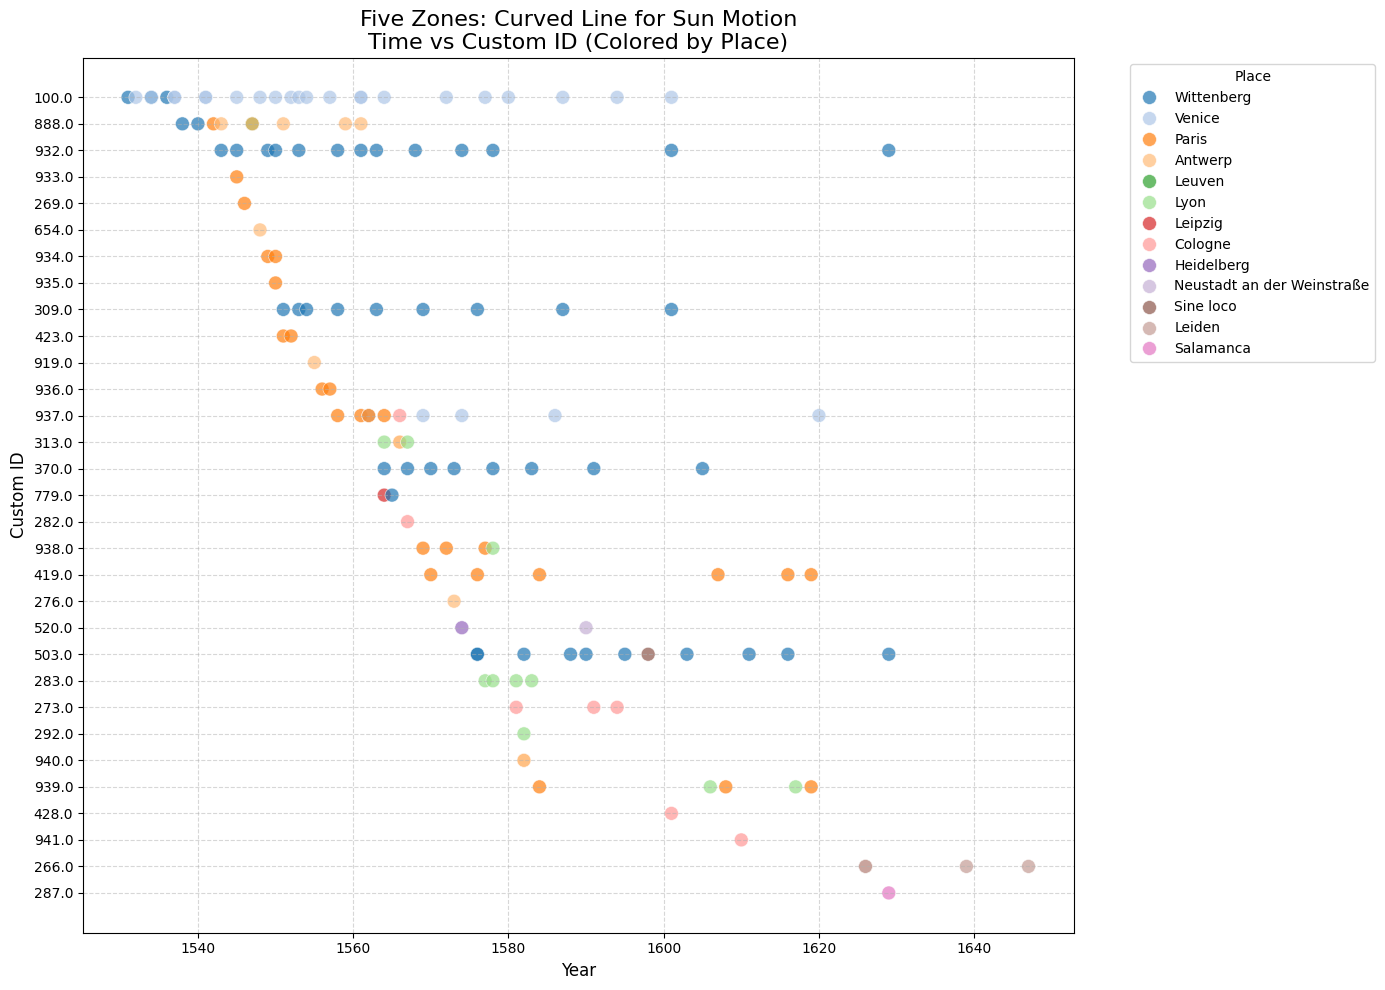

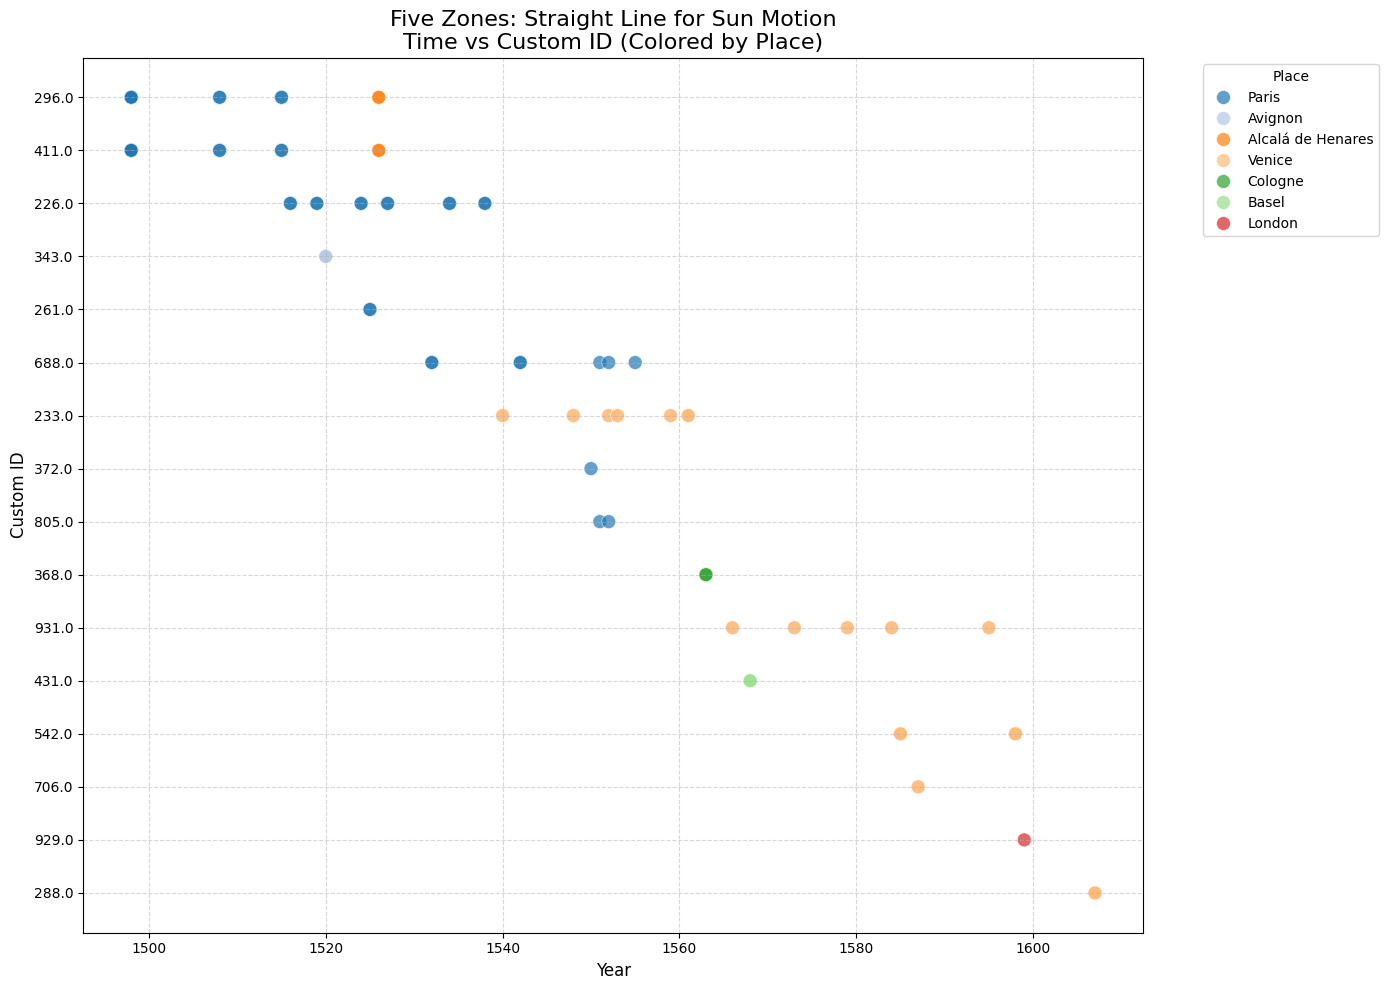

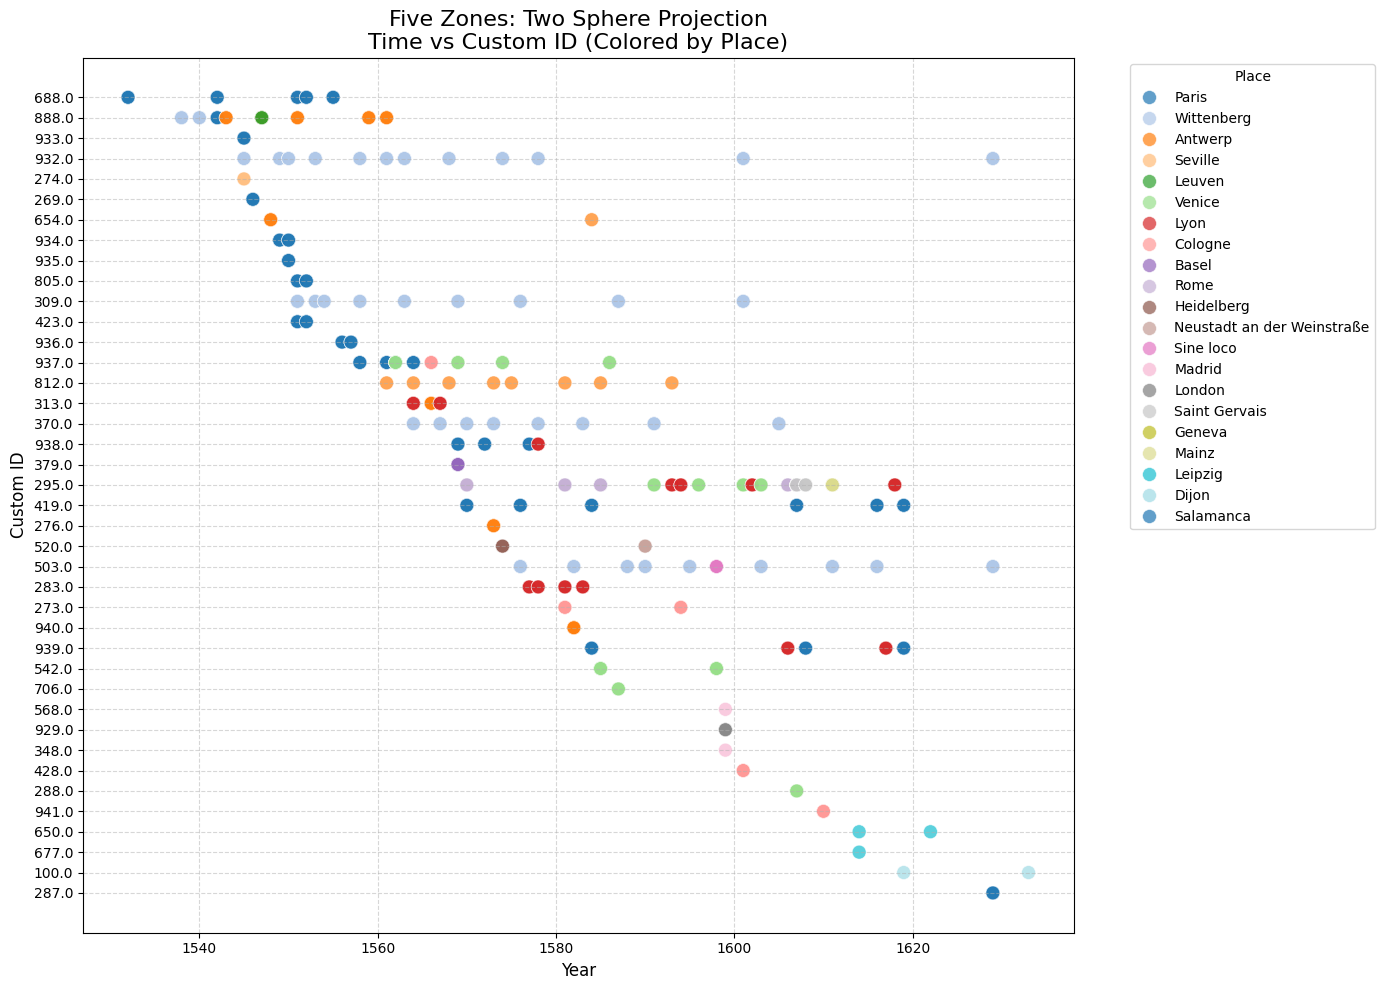

In [19]:
# Function to generate and save individual plots
def save_individual_plot(df, cat_name, file_name, title):
    subset = df[df['category'].str.contains(cat_name, na=False)].copy()
    if subset.empty:
        print(f"No data for {cat_name}")
        return
        
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=subset,
        x='year',
        y='custom_identifier_str',
        hue='place',
        palette='tab20',
        s=100,
        alpha=0.7,
        edgecolor='w',
        linewidth=0.5
    )
    plt.title(f'{title}\nTime vs Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Place')
    plt.tight_layout()
    plt.savefig(file_name, dpi=300)
    plt.show()

# Generate the three requested plots
save_individual_plot(plot_df, 'Curved Line', 'five_zones_curved_line.png', 'Five Zones: Curved Line for Sun Motion')
save_individual_plot(plot_df, 'Straight Line', 'five_zones_straight_line.png', 'Five Zones: Straight Line for Sun Motion')
save_individual_plot(plot_df, 'Double Sphere', 'five_zones_two_sphere.png', 'Five Zones: Two Sphere Projection')


## 6. Enhanced Plots (Y=Place and Dynamic Versions)

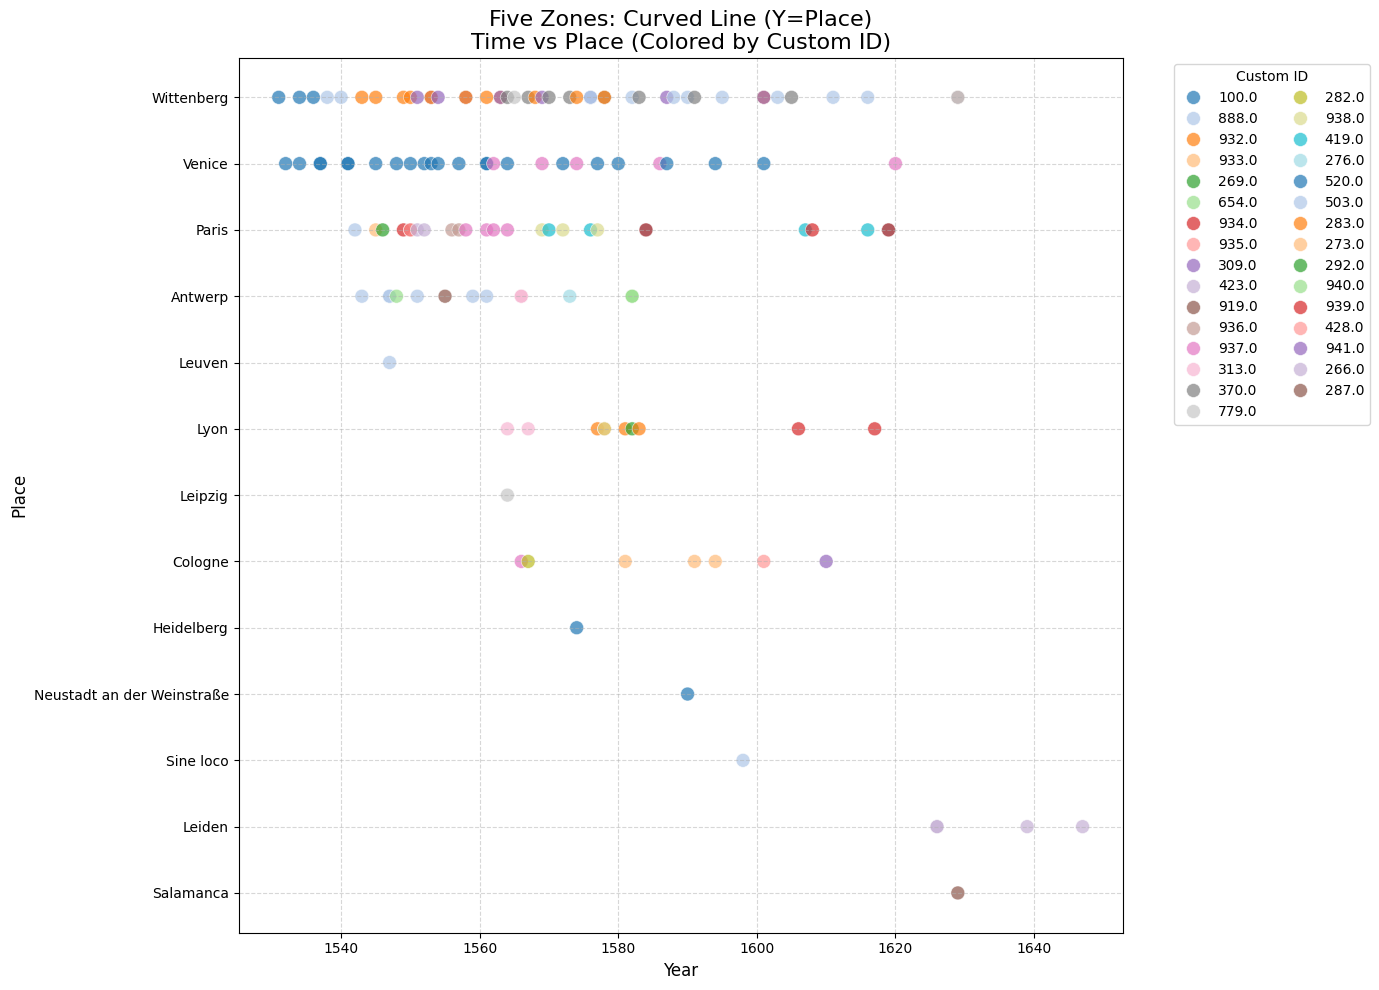

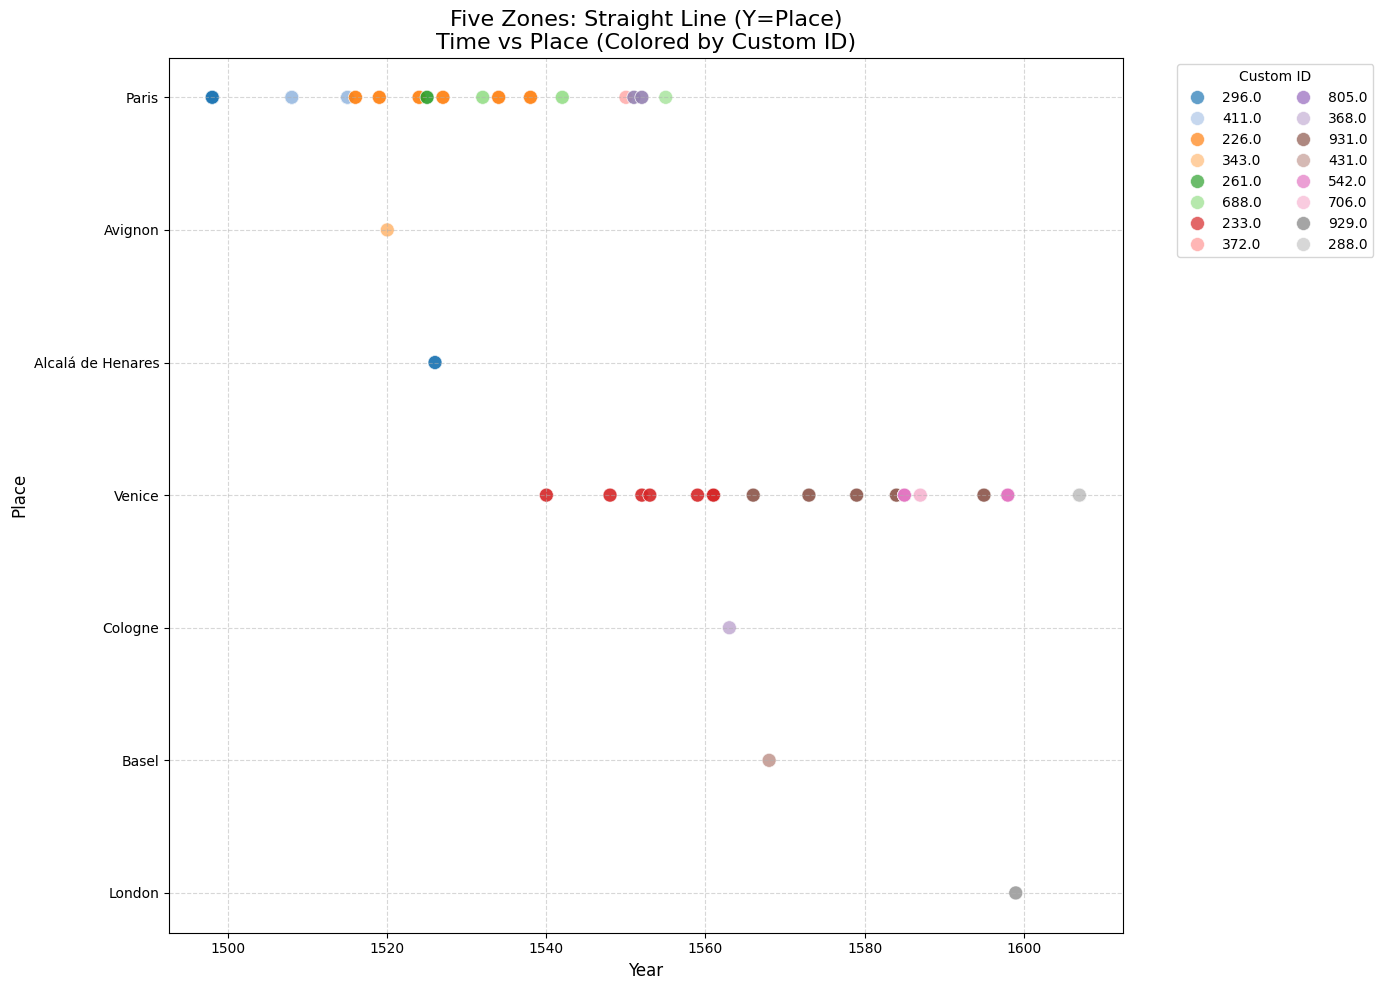

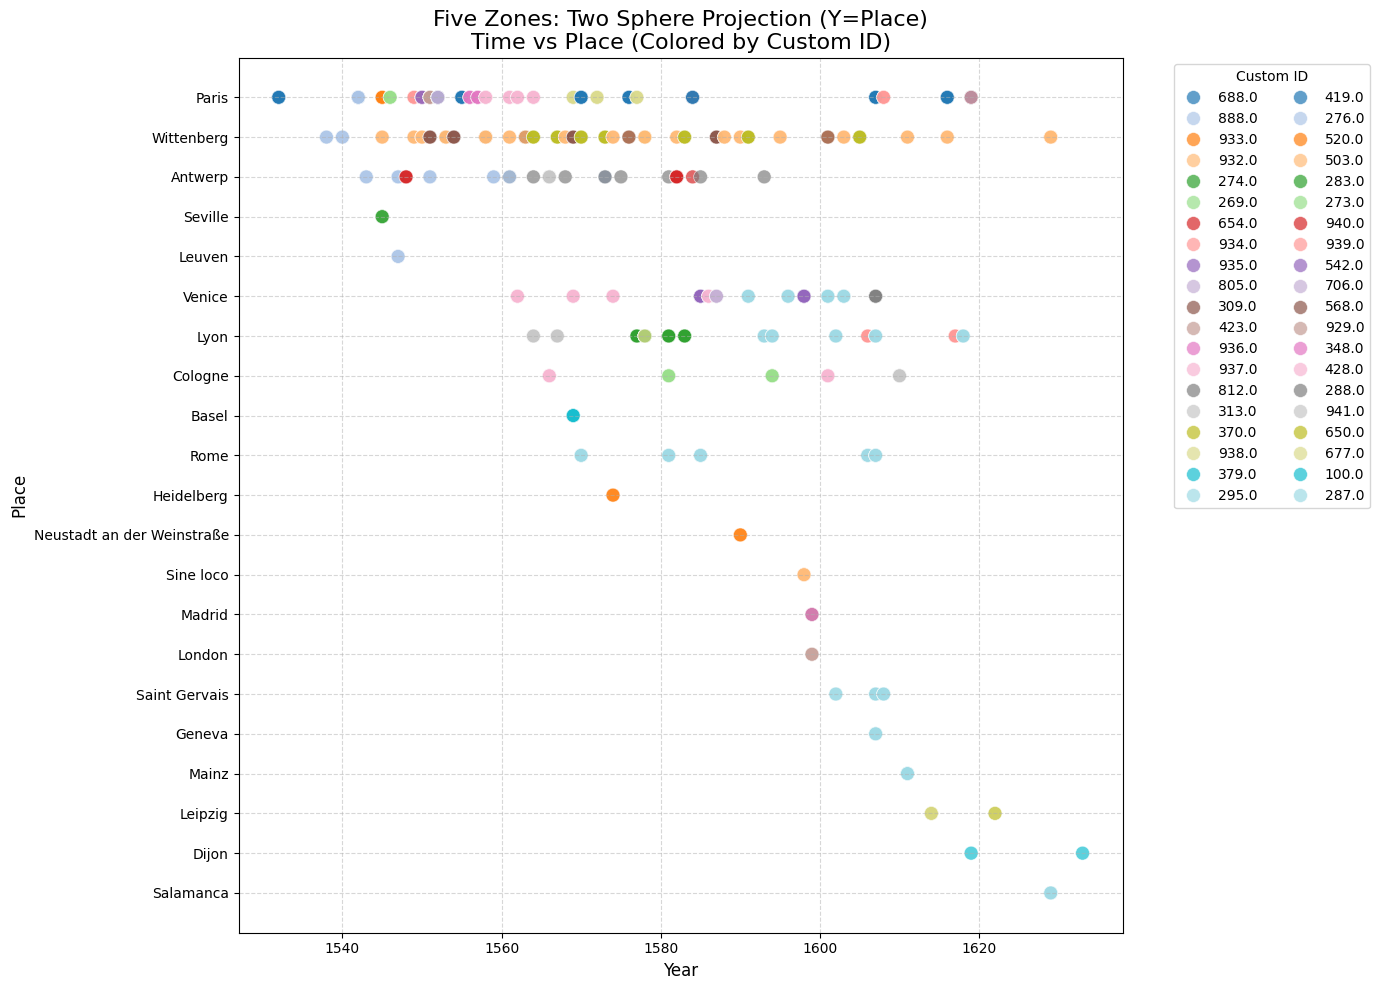

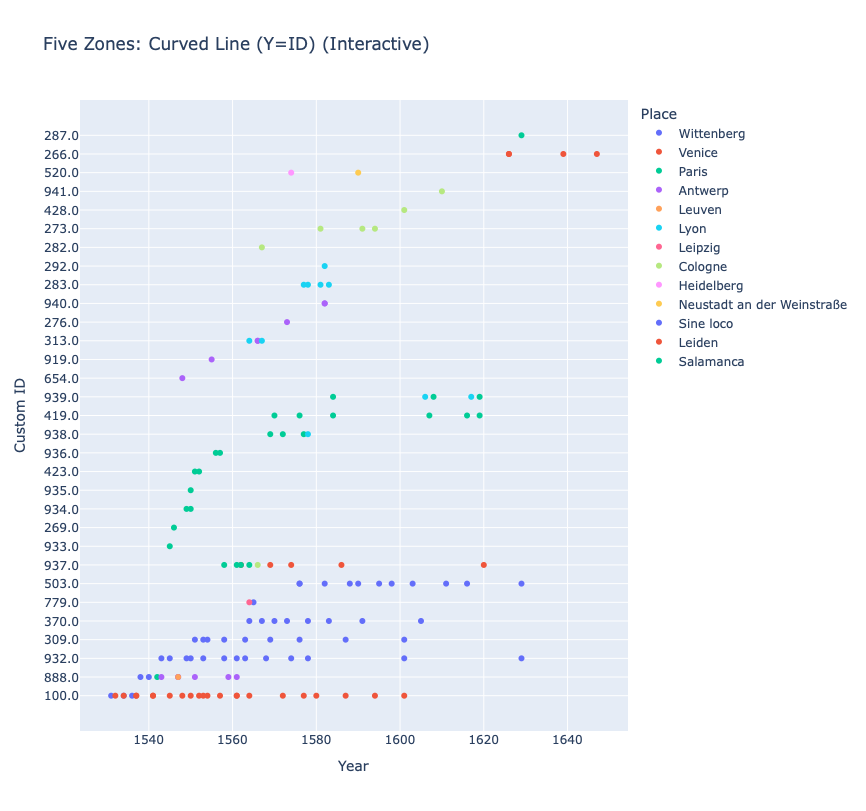

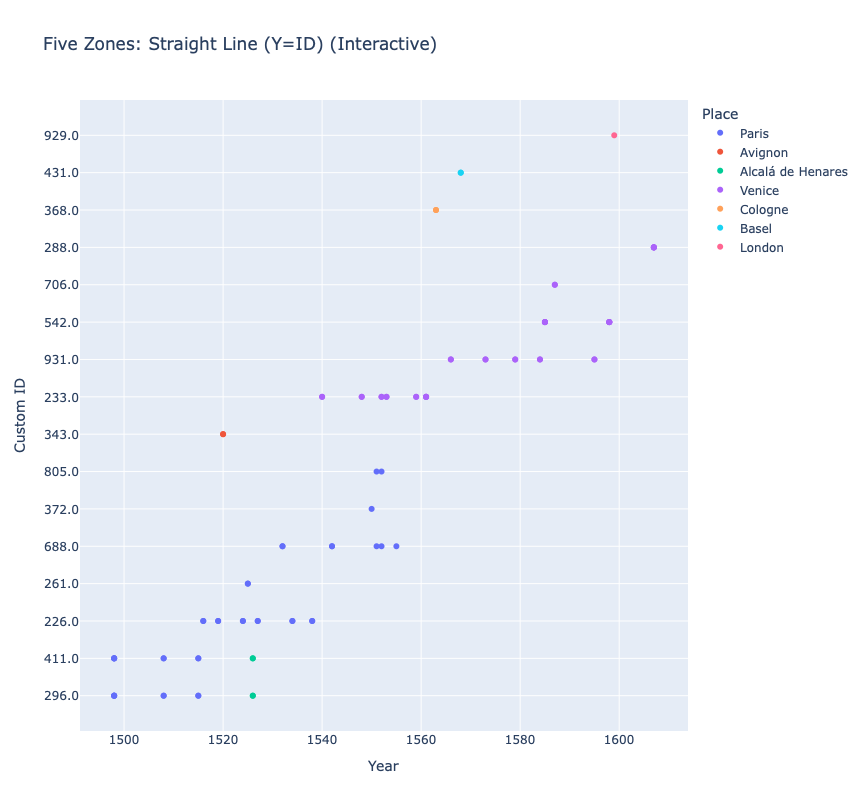

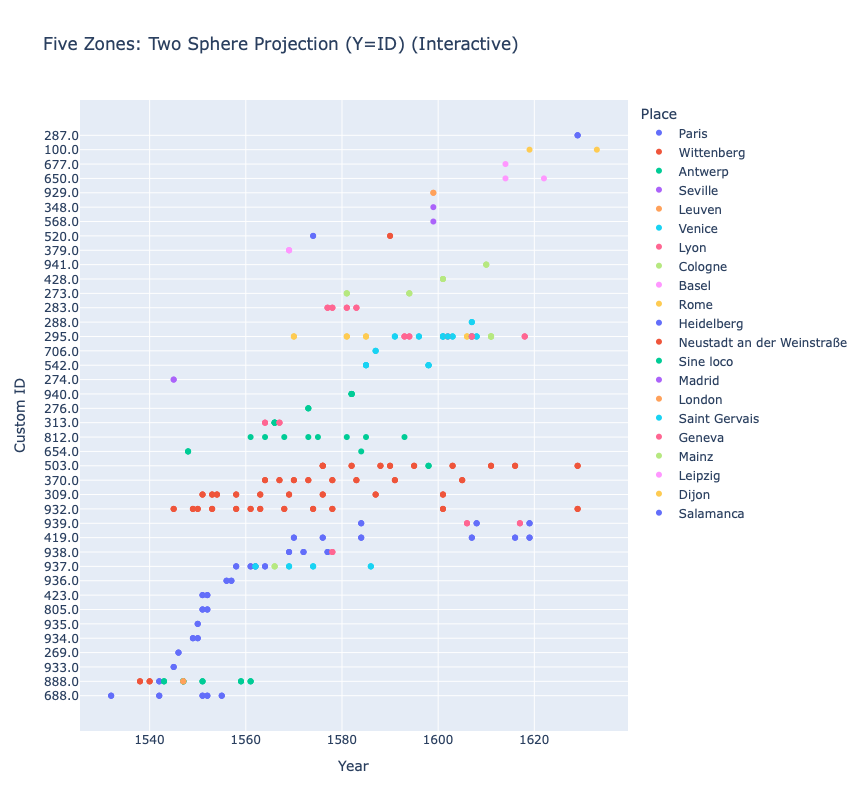

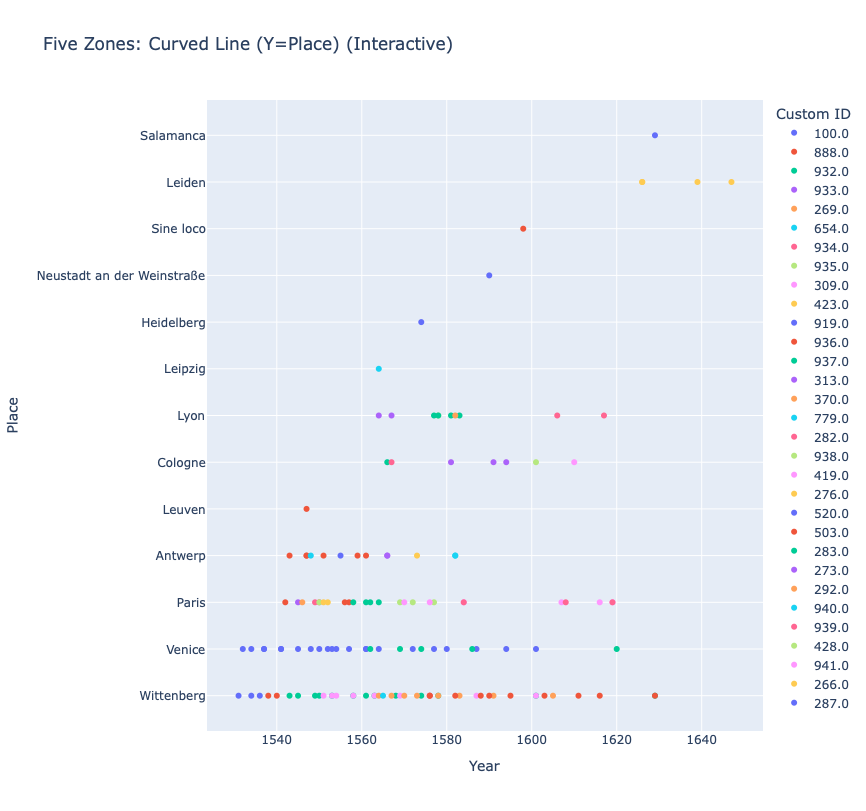

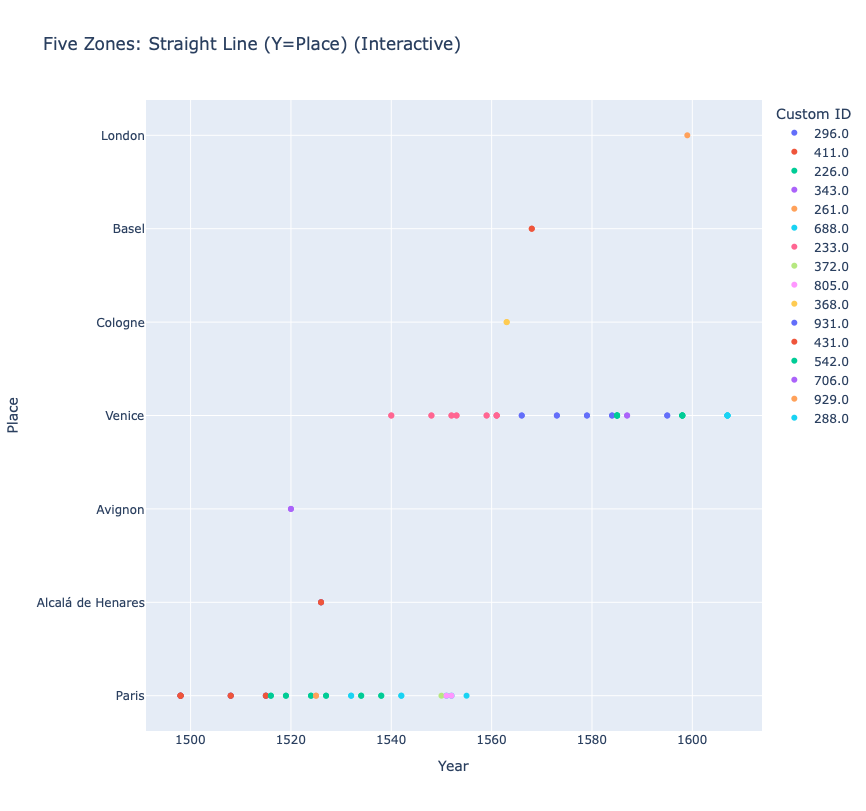

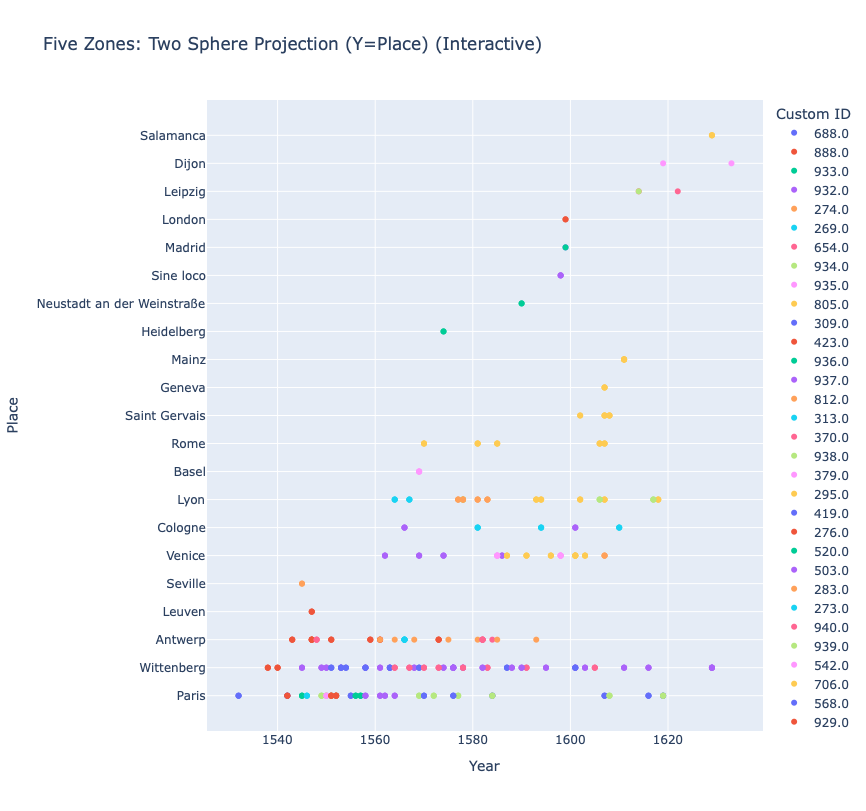

In [20]:
# Function for Y-Place static plots
def save_y_place_plot(df, cat_name, file_name, title):
    subset = df[df['category'].str.contains(cat_name, na=False)].copy()
    if subset.empty:
        print(f"No data for {cat_name}")
        return
        
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=subset,
        x='year',
        y='place',
        hue='custom_identifier_str',
        palette='tab20',
        s=100,
        alpha=0.7,
        edgecolor='w',
        linewidth=0.5
    )
    plt.title(f'{title} (Y=Place)\nTime vs Place (Colored by Custom ID)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Custom ID', ncol=2)
    plt.tight_layout()
    plt.savefig(file_name, dpi=300)
    plt.show()

# Function for Dynamic (Interactive) plots
def show_dynamic_plot(df, cat_name, title, y_col='custom_identifier_str', color_col='place'):
    subset = df[df['category'].str.contains(cat_name, na=False)].copy()
    if subset.empty:
        print(f"No data for {cat_name}")
        return
        
    fig = px.scatter(
        subset,
        x='year',
        y=y_col,
        color=color_col,
        hover_data=['cluster_name', 'category', 'part_or_adaption_label', 'book'],
        title=f'{title} (Interactive)',
        labels={'custom_identifier_str': 'Custom ID', 'year': 'Year', 'place': 'Place'}
    )
    fig.update_layout(height=800)
    fig.show()

# 1. Generate Y=Place Static Plots
save_y_place_plot(plot_df, 'Curved Line', 'five_zones_curved_y_place.png', 'Five Zones: Curved Line')
save_y_place_plot(plot_df, 'Straight Line', 'five_zones_straight_y_place.png', 'Five Zones: Straight Line')
save_y_place_plot(plot_df, 'Double Sphere', 'five_zones_two_sphere_y_place.png', 'Five Zones: Two Sphere Projection')

# 2. Generate/Show Dynamic Plots (Y=ID version)
show_dynamic_plot(plot_df, 'Curved Line', 'Five Zones: Curved Line (Y=ID)')
show_dynamic_plot(plot_df, 'Straight Line', 'Five Zones: Straight Line (Y=ID)')
show_dynamic_plot(plot_df, 'Double Sphere', 'Five Zones: Two Sphere Projection (Y=ID)')

# 3. Generate/Show Dynamic Plots (Y=Place version)
show_dynamic_plot(plot_df, 'Curved Line', 'Five Zones: Curved Line (Y=Place)', y_col='place', color_col='custom_identifier_str')
show_dynamic_plot(plot_df, 'Straight Line', 'Five Zones: Straight Line (Y=Place)', y_col='place', color_col='custom_identifier_str')
show_dynamic_plot(plot_df, 'Double Sphere', 'Five Zones: Two Sphere Projection (Y=Place)', y_col='place', color_col='custom_identifier_str')
